<a href="https://colab.research.google.com/github/Prabin-Hasham/shadenav/blob/main/notebooks/01_shadows_hasham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install -q osmnx pvlib

In [4]:

import geopandas as gpd
buildings = gpd.read_file("data/buildings.gpkg")
print(buildings.crs, "|", len(buildings), "buildings")

EPSG:32610 | 715 buildings


In [5]:
#Sun Position
import pandas as pd
from pvlib.solarposition import get_solarposition

CHICO_LAT, CHICO_LON, CHICO_TZ = 39.7285, -121.8375, "America/Los_Angeles"

def sun_position(when):
    idx = pd.DatetimeIndex([when]).tz_localize(CHICO_TZ)
    r = get_solarposition(idx, CHICO_LAT, CHICO_LON)
    return float(r["apparent_elevation"].iloc[0]), float(r["azimuth"].iloc[0])

In [6]:
from datetime import datetime
for h in [9, 12, 15, 18]:
    alt, az = sun_position(datetime(2025, 9, 15, h, 0))
    print(f"{h}:00 — alt {alt:.0f}°, az {az:.0f}°")

9:00 — alt 24°, az 108°
12:00 — alt 50°, az 155°
15:00 — alt 44°, az 223°
18:00 — alt 14°, az 262°


In [7]:
import math
from shapely.affinity import translate
from shapely.ops import unary_union

def cast_one(footprint, height_m, sun_alt_deg, sun_az_deg):
    # shadow length along the ground
    length = height_m / math.tan(math.radians(sun_alt_deg))

    # direction the shadow falls = opposite the sun.
    # azimuth is clockwise from north, so sun direction as (east, north)
    # is (sin az, cos az). Shadow is the negative of that.
    a = math.radians(sun_az_deg)
    dx = -length * math.sin(a)
    dy = -length * math.cos(a)

    # slide a copy of the footprint to where the shadow tip lands
    moved = translate(footprint, xoff=dx, yoff=dy)

    # the shadow is the footprint, the moved copy, and everything swept between
    return unary_union([footprint, moved]).convex_hull

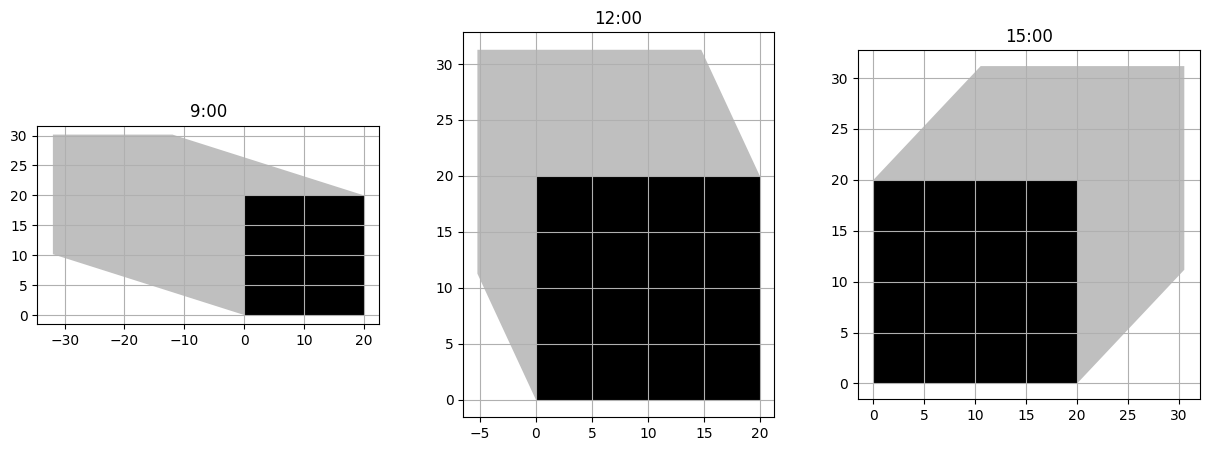

In [8]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from datetime import datetime

b = Polygon([(0,0),(20,0),(20,20),(0,20)])  # 20m square
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, h in zip(axes, [9, 12, 15]):
    alt, az = sun_position(datetime(2025, 9, 15, h))
    shadow = cast_one(b, 15, alt, az)
    gpd.GeoSeries([shadow]).plot(ax=ax, color="grey", alpha=0.5)
    gpd.GeoSeries([b]).plot(ax=ax, color="black")
    ax.set_title(f"{h}:00"); ax.set_aspect("equal"); ax.grid(True)
plt.show()

In [9]:
import math
import geopandas as gpd
from shapely.affinity import translate
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union

def cast_all(buildings, sun_alt_deg, sun_az_deg):
    if sun_alt_deg <= 3:
        return None
    a = math.radians(sun_az_deg)
    tan_alt = math.tan(math.radians(sun_alt_deg))

    parts = []
    for geom, h in zip(buildings.geometry, buildings.height_m):
        if geom is None or geom.is_empty:
            continue
        length = h / tan_alt
        dx, dy = -length * math.sin(a), -length * math.cos(a)

        polys = geom.geoms if isinstance(geom, MultiPolygon) else [geom]
        for p in polys:
            if not isinstance(p, Polygon) or p.is_empty:
                continue
            moved = translate(p, xoff=dx, yoff=dy)
            sub = [p, moved]
            coords = list(p.exterior.coords)
            for (x1,y1),(x2,y2) in zip(coords[:-1], coords[1:]):
                sub.append(Polygon([(x1,y1),(x2,y2),(x2+dx,y2+dy),(x1+dx,y1+dy)]))
            parts.append(unary_union(sub).buffer(0))

    return unary_union(parts)   # merge all buildings' shadows into one shape

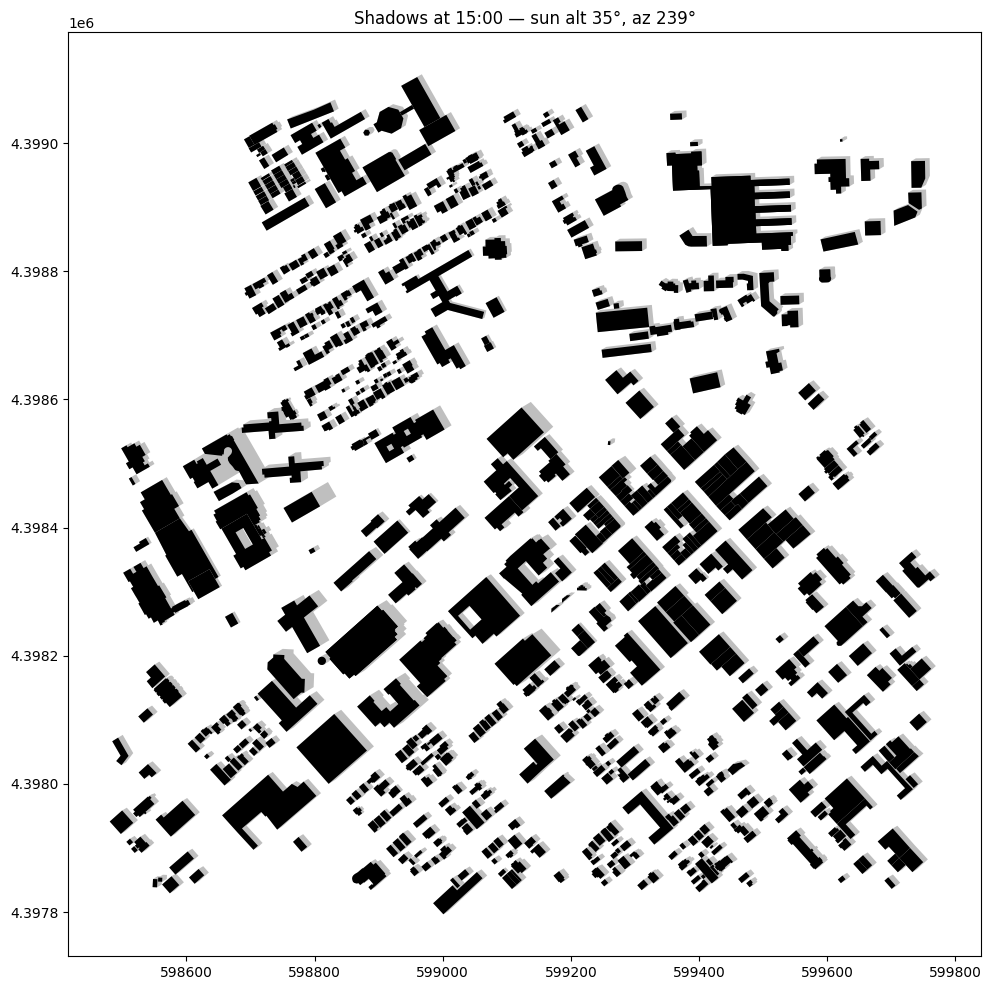

In [12]:
import matplotlib.pyplot as plt
from datetime import datetime

alt, az = sun_position(datetime(2025, 9, 15, 16))
shadow = cast_all(buildings, alt, az)

fig, ax = plt.subplots(figsize=(12, 12))
gpd.GeoSeries([shadow], crs=buildings.crs).plot(ax=ax, color="grey", alpha=0.5)
buildings.plot(ax=ax, color="black")
ax.set_title(f"Shadows at 15:00 — sun alt {alt:.0f}°, az {az:.0f}°")
ax.set_aspect("equal")
plt.show()

In [11]:
import time
t = time.time()
shadow = cast_all(buildings, alt, az)
print(f"{time.time()-t:.1f}s")

0.8s


In [13]:
def shadow_at(buildings, when):
    """The one function routing calls. Returns one (Multi)Polygon, or None if sun is down."""
    alt, az = sun_position(when)
    return cast_all(buildings, alt, az)

In [16]:
from datetime import datetime
s = shadow_at(buildings, datetime(2025, 9, 15, 9))
print(type(s), s.area if s else "no shadow")

<class 'shapely.geometry.multipolygon.MultiPolygon'> 536187.1725549703
